# Análisis estadístico de `run_benchmark` (más allá de `launch_viz`)

Este notebook carga `results_metadata.parquet` y calcula estadísticas globales y por grupos diagnósticos:
- totales reales de `Wins`, `Regressions`, `High_Uncertainty`, `Edge_Cases` (sin muestreo),
- comparación con los IDs guardados en `focus_groups_ids.json` (muestreados),
- medias/medianas de `oks_base`, `oks_ours`, `delta_oks`, `entropy`, `nll`, `covariance_vol`,
- visualizaciones para entender el comportamiento del modelo.

In [17]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook')

In [18]:
# Resolver raíz de proyecto
project_root = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
outputs_root = project_root / 'outputs'

# Busca runs con parquet
runs_with_parquet = []
for day in sorted(outputs_root.glob('*')):
    if not day.is_dir():
        continue
    for run in sorted(day.glob('*')):
        pq = run / 'results_metadata.parquet'
        if run.is_dir() and pq.exists():
            runs_with_parquet.append(run)

print(f'Runs con parquet encontrados: {len(runs_with_parquet)}')
for r in runs_with_parquet[-10:]:
    print('-', r.relative_to(project_root))

# Elige run automáticamente (el último con parquet) o asígnalo manualmente
if False: #runs_with_parquet:
    run_dir = runs_with_parquet[-2]
else:
    # Ejemplo manual (ajústalo si no hay detección automática)
    run_dir = project_root / 'outputs' / '2026-02-23' / '11-22-15'

print('Run seleccionado:', run_dir.relative_to(project_root) if run_dir.exists() else run_dir)

Runs con parquet encontrados: 78
- outputs\comparisons\23_FullStack_Conservative
- outputs\comparisons\24_FullStack_Moderate
- outputs\comparisons\25_FullStack_Aggressive
- outputs\comparisons\Baseline_Default
- outputs\comparisons\Photometric_Blur_3
- outputs\comparisons\Photometric_Brightness_10
- outputs\comparisons\Photometric_Brightness_30
- outputs\comparisons\Photometric_Contrast_0.8_1.2
- outputs\comparisons\Photometric_Noise_5
- outputs\comparisons\Photometric_None
Run seleccionado: outputs\2026-02-23\11-22-15


In [19]:
# Carga resultados masivos
parquet_path = run_dir / 'results_metadata.parquet'
assert parquet_path.exists(), f'No existe {parquet_path}'

df = pd.read_parquet(parquet_path)
print('Filas:', len(df))
print('Columnas:', list(df.columns))
df.head(3)

Filas: 2693
Columnas: ['image_id', 'dataset', 'oks_base', 'oks_ours', 'delta_oks', 'nll', 'entropy', 'covariance_vol', 'n_components', 'oks_base_nose', 'oks_ours_nose', 'delta_oks_nose', 'oks_base_left_eye', 'oks_ours_left_eye', 'delta_oks_left_eye', 'oks_base_right_eye', 'oks_ours_right_eye', 'delta_oks_right_eye', 'oks_base_left_ear', 'oks_ours_left_ear', 'delta_oks_left_ear', 'oks_base_right_ear', 'oks_ours_right_ear', 'delta_oks_right_ear', 'oks_base_left_shoulder', 'oks_ours_left_shoulder', 'delta_oks_left_shoulder', 'oks_base_right_shoulder', 'oks_ours_right_shoulder', 'delta_oks_right_shoulder', 'oks_base_left_elbow', 'oks_ours_left_elbow', 'delta_oks_left_elbow', 'oks_base_right_elbow', 'oks_ours_right_elbow', 'delta_oks_right_elbow', 'oks_base_left_wrist', 'oks_ours_left_wrist', 'delta_oks_left_wrist', 'oks_base_right_wrist', 'oks_ours_right_wrist', 'delta_oks_right_wrist', 'oks_base_left_hip', 'oks_ours_left_hip', 'delta_oks_left_hip', 'oks_base_right_hip', 'oks_ours_right_hi

,image_id,dataset,oks_base,oks_ours,delta_oks,nll,entropy,covariance_vol,n_components,oks_base_nose,...,delta_oks_left_knee,oks_base_right_knee,oks_ours_right_knee,delta_oks_right_knee,oks_base_left_ankle,oks_ours_left_ankle,delta_oks_left_ankle,oks_base_right_ankle,oks_ours_right_ankle,delta_oks_right_ankle
0,532481,coco,0.616605,0.630612,0.014007,0.0,3.542440,2.022962,1,NaN,...,-0.026613,0.838958,0.771702,-0.067256,0.992275,0.958837,-0.033438,0.800954,0.884805,0.083851
1,458755,coco,0.731881,0.729767,-0.002114,0.0,3.338631,1.649965,1,NaN,...,-0.025562,0.023290,0.053271,0.029981,NaN,NaN,NaN,0.265096,0.000230,-0.264867
2,385029,coco,0.774812,0.822562,0.047750,0.0,6.298415,16.087927,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
# Definiciones diagnósticas (mismas reglas que diagnostics.py)
OKS_IMPROVEMENT_THRESHOLD = 0.1
OKS_FAILURE_THRESHOLD = 0.5
COV_VOL_QUANTILE = 0.90

wins_mask = df['oks_ours'] > (df['oks_base'] + OKS_IMPROVEMENT_THRESHOLD)
reg_mask = df['oks_base'] > (df['oks_ours'] + OKS_IMPROVEMENT_THRESHOLD)

if 'covariance_vol' in df.columns:
    cov_threshold = float(df['covariance_vol'].quantile(COV_VOL_QUANTILE))
    hu_mask = df['covariance_vol'] > cov_threshold
else:
    cov_threshold = np.nan
    hu_mask = pd.Series(False, index=df.index)

ec_mask = (df['oks_base'] < OKS_FAILURE_THRESHOLD) & (df['oks_ours'] < OKS_FAILURE_THRESHOLD)

totals = pd.DataFrame({
    'group': ['Wins', 'Regressions', 'High_Uncertainty', 'Edge_Cases'],
    'count_total_candidates': [int(wins_mask.sum()), int(reg_mask.sum()), int(hu_mask.sum()), int(ec_mask.sum())],
})

totals

,group,count_total_candidates
0,Wins,53
1,Regressions,88
2,High_Uncertainty,270
3,Edge_Cases,527


In [21]:
# Comparar contra focus_groups_ids.json (si existe, suele venir muestreado)
focus_path = run_dir / 'focus_groups_ids.json'
if focus_path.exists():
    with open(focus_path, 'r', encoding='utf-8') as f:
        focus = json.load(f)

    sampled = pd.DataFrame({
        'group': ['Wins', 'Regressions', 'High_Uncertainty', 'Edge_Cases'],
        'count_saved_in_focus_groups_ids': [
            len(focus.get('Wins', [])),
            len(focus.get('Regressions', [])),
            len(focus.get('High_Uncertainty', [])),
            len(focus.get('Edge_Cases', [])),
        ]
    })
    comparison = totals.merge(sampled, on='group', how='left')
else:
    comparison = totals.copy()
    comparison['count_saved_in_focus_groups_ids'] = np.nan

comparison

,group,count_total_candidates,count_saved_in_focus_groups_ids
0,Wins,53,50
1,Regressions,88,50
2,High_Uncertainty,270,50
3,Edge_Cases,527,50


In [22]:
# Estadísticas globales de métricas clave
metric_cols = [c for c in ['oks_base', 'oks_ours', 'delta_oks', 'nll', 'entropy', 'covariance_vol', 'n_components'] if c in df.columns]
stats = df[metric_cols].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
stats = stats.rename(columns={'50%': 'median'})
stats

,mean,std,min,25%,median,75%,max
oks_base,0.692073,0.328532,0.000000,0.650226,0.843720,0.911968,0.997934
oks_ours,0.681231,0.322856,0.000000,0.631709,0.825954,0.898739,0.994942
delta_oks,-0.010841,0.052519,-0.524393,-0.031188,-0.007609,0.004056,0.471178
nll,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
entropy,3.483411,0.538913,3.026331,3.202631,3.282365,3.489902,7.393705
covariance_vol,2.080222,3.677167,0.709834,1.432080,1.548952,1.769278,111.496986
n_components,1.008541,0.092037,1.000000,1.000000,1.000000,1.000000,2.000000


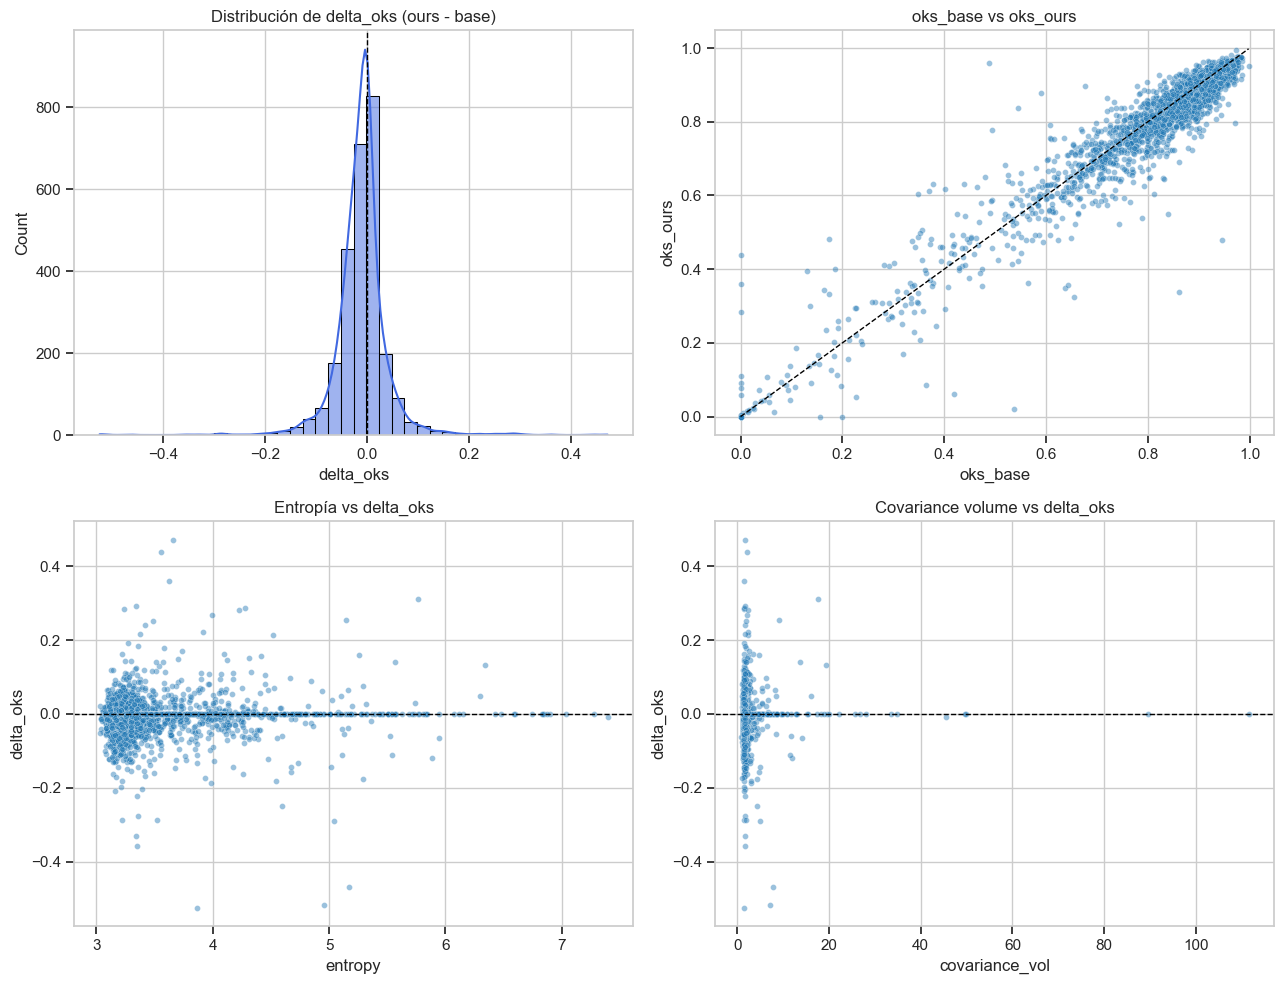

In [23]:
# Visualizaciones útiles para análisis
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# 1) Histograma delta_oks
if 'delta_oks' in df.columns:
    sns.histplot(df['delta_oks'], bins=40, kde=True, ax=axes[0, 0], color='royalblue')
    axes[0, 0].axvline(0.0, color='black', linestyle='--', linewidth=1)
    axes[0, 0].set_title('Distribución de delta_oks (ours - base)')

# 2) Scatter oks_base vs oks_ours
if {'oks_base', 'oks_ours'}.issubset(df.columns):
    sns.scatterplot(data=df, x='oks_base', y='oks_ours', s=18, alpha=0.45, ax=axes[0, 1])
    lim_low = min(df['oks_base'].min(), df['oks_ours'].min())
    lim_high = max(df['oks_base'].max(), df['oks_ours'].max())
    axes[0, 1].plot([lim_low, lim_high], [lim_low, lim_high], 'k--', linewidth=1)
    axes[0, 1].set_title('oks_base vs oks_ours')

# 3) Entropía vs delta_oks
if {'entropy', 'delta_oks'}.issubset(df.columns):
    sns.scatterplot(data=df, x='entropy', y='delta_oks', s=18, alpha=0.45, ax=axes[1, 0])
    axes[1, 0].axhline(0.0, color='black', linestyle='--', linewidth=1)
    axes[1, 0].set_title('Entropía vs delta_oks')

# 4) Covariance volume vs delta_oks
if {'covariance_vol', 'delta_oks'}.issubset(df.columns):
    sns.scatterplot(data=df, x='covariance_vol', y='delta_oks', s=18, alpha=0.45, ax=axes[1, 1])
    axes[1, 1].axhline(0.0, color='black', linestyle='--', linewidth=1)
    axes[1, 1].set_title('Covariance volume vs delta_oks')

plt.tight_layout()
plt.show()

In [24]:
# Top casos para inspección manual
cols = [c for c in ['image_id', 'dataset', 'oks_base', 'oks_ours', 'delta_oks', 'entropy', 'nll', 'covariance_vol'] if c in df.columns]

print('Top 10 mejoras (delta_oks alto):')
display(df.sort_values('delta_oks', ascending=False)[cols].head(10))

print('Top 10 regresiones (delta_oks bajo):')
display(df.sort_values('delta_oks', ascending=True)[cols].head(10))

Top 10 mejoras (delta_oks alto):


,image_id,dataset,oks_base,oks_ours,delta_oks,entropy,nll,covariance_vol
2497,253386,coco,0.487259,0.958437,0.471178,3.661654,0.0,1.686107
2548,581206,coco,0.000018,0.439219,0.439202,3.555755,0.0,2.050078
535,42528,coco,0.000003,0.360186,0.360183,3.622721,0.0,1.552194
1596,267169,coco,0.172775,0.483197,0.310422,5.761409,0.0,17.688677
2286,121673,coco,0.545531,0.838372,0.292841,3.339808,0.0,1.651909
522,255483,coco,0.589594,0.877471,0.287877,4.277484,0.0,1.351545
53,90284,coco,0.494306,0.778637,0.284331,3.239214,0.0,1.493820
1137,568710,coco,0.000375,0.282751,0.282375,4.222843,0.0,2.269767
489,476514,coco,0.129604,0.396083,0.266479,3.995030,0.0,2.036900
2441,32038,coco,0.349054,0.603081,0.254027,5.141396,0.0,9.104082


Top 10 regresiones (delta_oks bajo):


,image_id,dataset,oks_base,oks_ours,delta_oks,entropy,nll,covariance_vol
927,477955,coco,0.861181,0.336788,-0.524393,3.861141,0.0,1.393818
1489,381587,coco,0.536502,0.019356,-0.517145,4.957086,0.0,7.023215
2592,163562,coco,0.945791,0.477975,-0.467815,5.172902,0.0,7.791162
1409,151938,coco,0.419226,0.061006,-0.358219,3.347853,0.0,1.665250
1650,259097,coco,0.655715,0.325700,-0.330015,3.341730,0.0,1.655085
2150,309678,coco,0.840346,0.550807,-0.289539,5.040463,0.0,4.975877
2300,203639,coco,0.643585,0.355803,-0.287782,3.520453,0.0,1.978969
1028,330818,coco,0.637377,0.349627,-0.287750,3.222358,0.0,1.468852
1203,167572,coco,0.364081,0.086911,-0.277170,3.356787,0.0,1.680195
45,450686,coco,0.789159,0.538915,-0.250243,4.592768,0.0,4.372026
